# Lab Instructions

Find a dataset that interests you. I'd recommend starting on Kaggle. Read through all of the material about the dataset and download a .csv file.

1. Write a short summary of the data. Where did it come from? How was it collected? What are the features in the data? Why is this dataset interesting to you?
2. Identify 5 interesting questions about your data that you can answer using Pandas methods.
3. Answer those questions! You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers. LLMs will not always write code in this way without specific instruction.
4. Write the answer to your question in a text box underneath the code you used to calculate the answer.

## Dataset Description

**Dataset:** [Video Game Sales](https://www.kaggle.com/datasets/gregorut/videogamesales) (`vgsales.csv`), originally posted on Kaggle by user Gregory Smith.

**Where it came from / how it was collected:** The data was generated by scraping [vgchartz.com](https://www.vgchartz.com/), a website that tracks video game sales estimates. The dataset only includes games with **more than 100,000 copies sold**, and covers releases from **1980 through 2020**.

**Features in the data:**
* `Rank` - overall sales rank of the game
* `Name` - the title of the game
* `Platform` - the console/system it was released on (e.g. Wii, PS4, X360, PC)
* `Year` - the year the game was released
* `Genre` - the genre of the game (Action, Sports, Racing, etc.)
* `Publisher` - the company that published the game
* `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales` - sales (in millions of copies) in North America, Europe, Japan, and the rest of the world respectively
* `Global_Sales` - total worldwide sales (in millions of copies)

There are **16,598 games** in the dataset. A small number of rows are missing a `Year` (271 rows) or `Publisher` (58 rows).

**Why this dataset is interesting:** I'm interested in video games, and this dataset lets me dig into questions like which genres and platforms have historically sold best, how the industry has changed over time, and which publishers have been the most successful - the kind of thing that's fun to explore as a gamer and also mirrors real business questions a game studio might ask.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('vgsales.csv')
print(df.shape)
df.head()

(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


The dataset has 16,598 rows and 11 columns, matching the description above. Let's check for missing 
values before diving into our questions.

In [2]:
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

As expected, `Year` is missing for 271 games and `Publisher` is missing for 58 games. We'll drop 
missing values for a given question only when that question actually depends on the column that's 
missing, so we don't lose data unnecessarily.

## Question 1: Which genre has generated the most total global sales?

I want to know which genre of game has been the most commercially successful overall, across the 
whole history of the dataset.

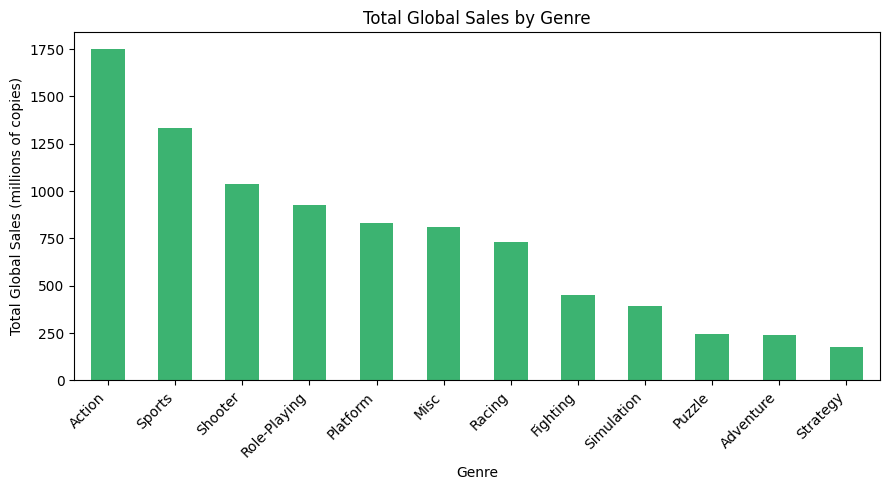

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       392.20
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64

In [3]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
genre_sales.plot(kind='bar', color='mediumseagreen')
plt.ylabel('Total Global Sales (millions of copies)')
plt.xlabel('Genre')
plt.title('Total Global Sales by Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

genre_sales

**Answer:** **Action** games have generated the most total global sales by far, with about 1,751 
million copies sold across the dataset, followed by **Sports** (~1,331 million) and **Shooter** 
(~1,037 million). **Strategy** games have sold the least overall (~175 million), which makes sense - 
strategy titles tend to appeal to a smaller, more niche audience than mass-market action or sports 
games.

## Question 2: How have total global video game sales changed over time?

I want to see whether the video game industry (at least as represented by this dataset) has grown, 
shrunk, or stayed flat in terms of total copies sold per year.

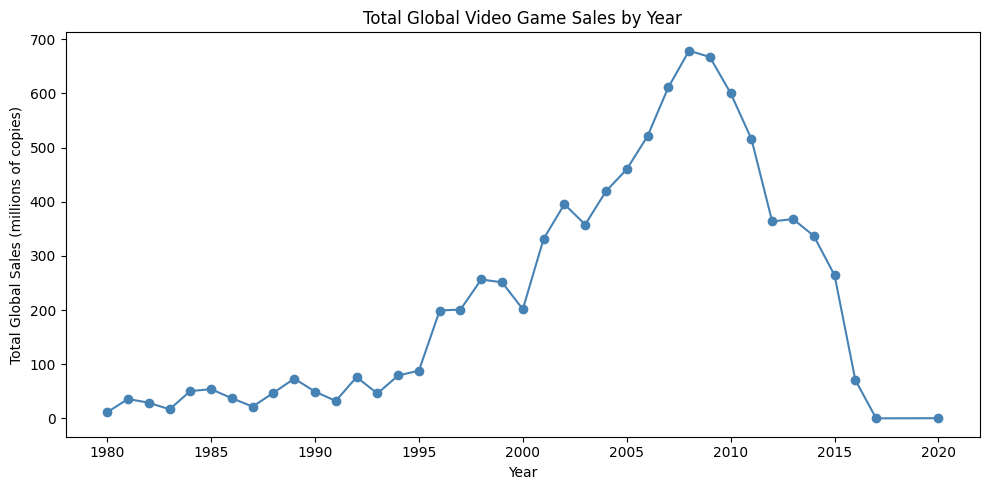

Year
2009.0    667.30
2010.0    600.45
2011.0    515.99
2012.0    363.54
2013.0    368.11
2014.0    337.05
2015.0    264.44
2016.0     70.93
2017.0      0.05
2020.0      0.29
Name: Global_Sales, dtype: float64

In [4]:
yearly_sales = df.dropna(subset=['Year']).groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot(kind='line', marker='o', color='steelblue')
plt.ylabel('Total Global Sales (millions of copies)')
plt.xlabel('Year')
plt.title('Total Global Video Game Sales by Year')
plt.tight_layout()
plt.show()

yearly_sales.tail(10)

**Answer:** Total global sales climbed steadily from the early 1980s, accelerated through the 
2000s, and **peaked around 2008-2009** (roughly 679 million and 667 million copies sold, 
respectively). After that, sales steadily decline year over year through 2015-2016. The sharp drop-off 
after 2016 (down to under 1 million copies in 2017 and 2020) isn't a real industry collapse - it's a 
sign that this dataset simply stops being reliably updated/complete after that point, since it was 
scraped at a specific point in time and newer games hadn't accumulated the same sales history yet.

## Question 3: Which gaming platform has the highest total global sales?

I want to know which console (or PC) has hosted the best-selling games overall.

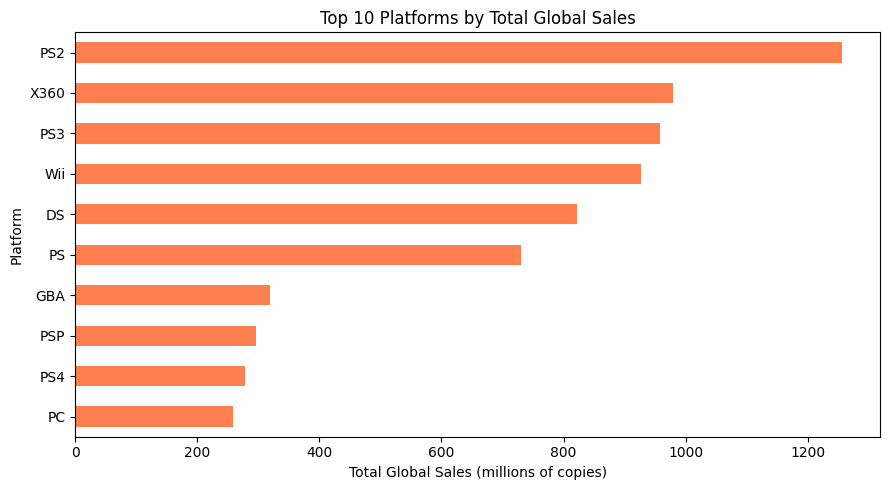

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64

In [5]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
platform_sales.sort_values().plot(kind='barh', color='coral')
plt.xlabel('Total Global Sales (millions of copies)')
plt.ylabel('Platform')
plt.title('Top 10 Platforms by Total Global Sales')
plt.tight_layout()
plt.show()

platform_sales

**Answer:** The **PlayStation 2 (PS2)** has the highest total global sales of any platform in the 
dataset, with about 1,256 million copies sold across all its games - noticeably ahead of the 
**Xbox 360** (~980 million) and **PlayStation 3** (~958 million). This tracks with the PS2's real-world 
reputation as the best-selling game console of all time, thanks to its very long lifespan and massive 
game library.

## Question 4: Which publisher has released the most games, and is that the same publisher with the most total sales?

I want to see if being prolific (releasing lots of games) lines up with being the most commercially 
successful publisher overall.

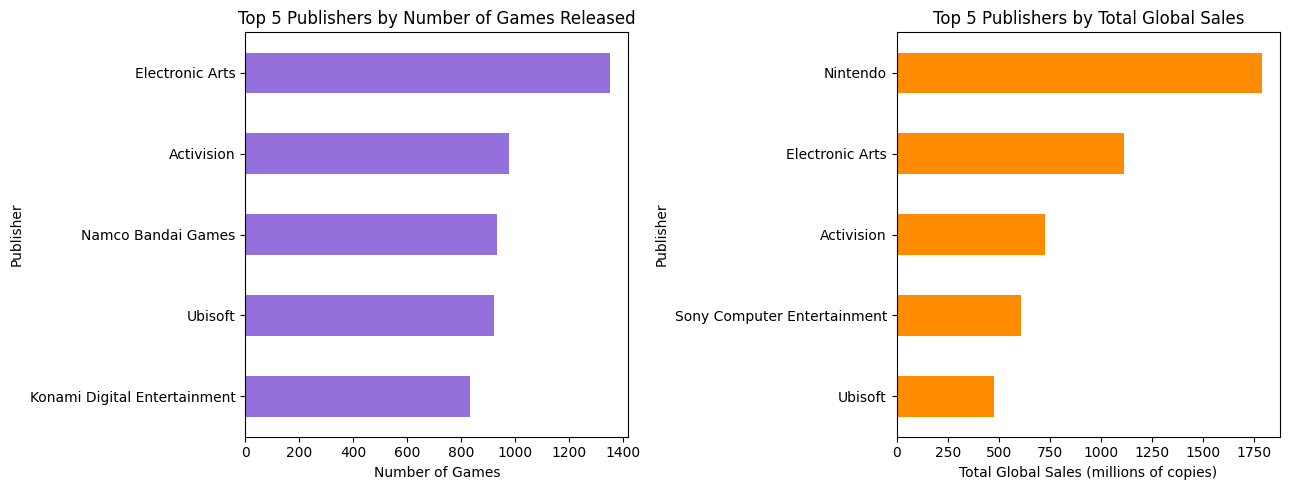

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
Name: count, dtype: int64

Publisher
Nintendo                       1786.56
Electronic Arts                1110.32
Activision                      727.46
Sony Computer Entertainment     607.50
Ubisoft                         474.72
Name: Global_Sales, dtype: float64


In [6]:
top_publishers_by_count = df['Publisher'].value_counts().head(5)
top_publishers_by_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

top_publishers_by_count.sort_values().plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Top 5 Publishers by Number of Games Released')
axes[0].set_xlabel('Number of Games')

top_publishers_by_sales.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 5 Publishers by Total Global Sales')
axes[1].set_xlabel('Total Global Sales (millions of copies)')

plt.tight_layout()
plt.show()

print(top_publishers_by_count)
print()
print(top_publishers_by_sales)

**Answer:** **Electronic Arts** has released the most games in the dataset (1,351 titles), followed 
by Activision, Namco Bandai, and Ubisoft. But Electronic Arts is **not** the top publisher by total 
sales - that title goes to **Nintendo**, whose 703 games generated about 1,787 million copies sold in 
total, well ahead of Electronic Arts' ~1,110 million from over 1,350 games. In other words, Nintendo 
sells far more copies *per game* on average than Electronic Arts does, even though EA released almost 
twice as many titles. Being prolific and being the top seller are clearly two different things here.

## Question 5: How are total sales distributed across the four sales regions (NA, EU, Japan, Other)?

I want to understand which region has historically bought the most copies of these games overall.

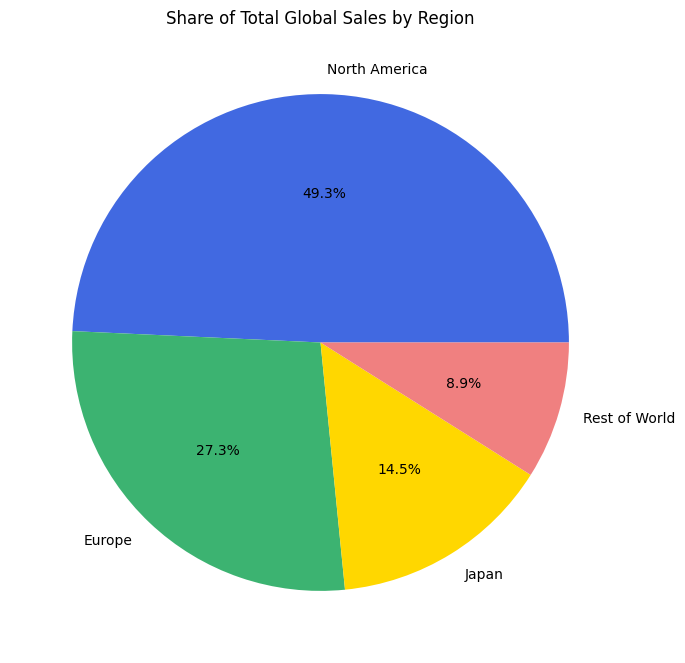

North America    4392.95
Europe           2434.13
Japan            1291.02
Rest of World     797.75
dtype: float64

In [7]:
region_totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
region_totals.index = ['North America', 'Europe', 'Japan', 'Rest of World']

plt.figure(figsize=(7,7))
plt.pie(region_totals, labels=region_totals.index, autopct='%1.1f%%',
        colors=['royalblue', 'mediumseagreen', 'gold', 'lightcoral'])
plt.title('Share of Total Global Sales by Region')
plt.tight_layout()
plt.show()

region_totals

**Answer:** **North America** accounts for the largest share of sales by far - about 49% of all 
copies sold in the dataset (roughly 4,393 million copies) - followed by **Europe** at about 27% 
(~2,434 million), **Japan** at about 14% (~1,291 million), and the **rest of the world** at only about 
9% (~798 million). This makes sense given that this is primarily a North American/European-centric 
sales dataset (scraped from vgchartz.com), and reflects North America's status as historically the 
largest video game market by volume.